Step 1: Loading and Formatting the Timeline

In [2]:
#importing modules
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# 1. Load the hourly data
df=pd.read_csv('hour.csv')

# 2. Combine the date ('dteday') and the hour ('hr') into a single datetime column
df['datetime']=pd.to_datetime(df['dteday'])+pd.to_timedelta(df['hr'],unit='h')

# 3. Set this new datetime column as the index (the backbone of time series)
df.set_index('datetime',inplace=True)

# 4. Sort the data chronologically (Oldest to Newest)
df.sort_index(inplace=True)

# 5. Drop 'instant' (it's just a row ID) and 'dteday' (since we made a better datetime index)
df.drop(['instant','dteday'],axis=1,inplace=True)

df.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
datetime,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
2011-01-01 01:00:00,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2011-01-01 02:00:00,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
2011-01-01 03:00:00,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
2011-01-01 04:00:00,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


Step 2: Exploratory Data Analysis

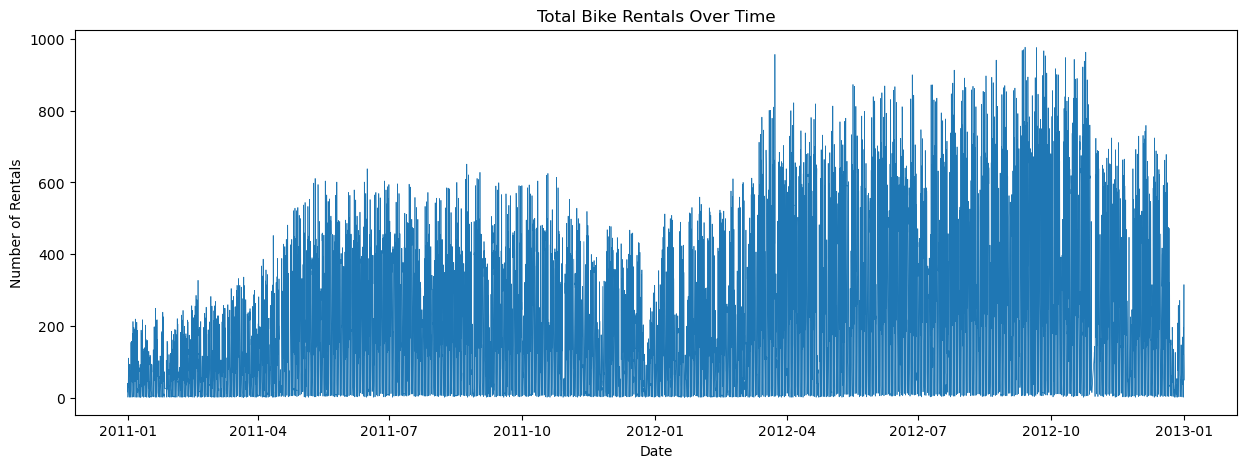

In [7]:
# 1. The "Big Picture" Plot 
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['cnt'], linewidth=0.5)
plt.title('Total Bike Rentals Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Rentals')
plt.show()

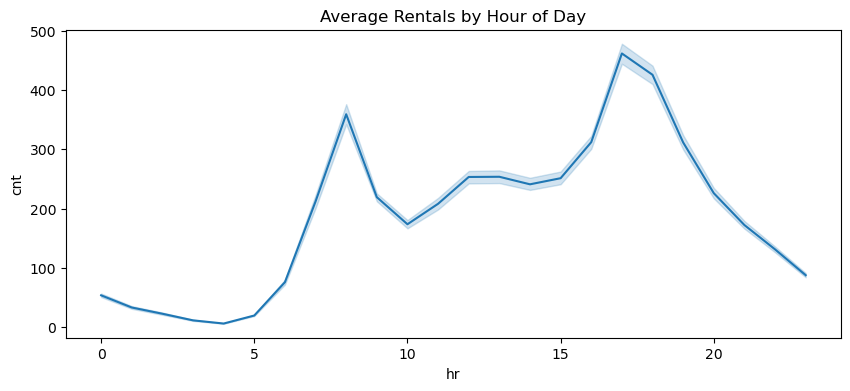

In [8]:
# 2. Hourly Patterns 
plt.figure(figsize=(10, 4))
sns.lineplot(data=df, x='hr', y='cnt')
plt.title('Average Rentals by Hour of Day')
plt.show()

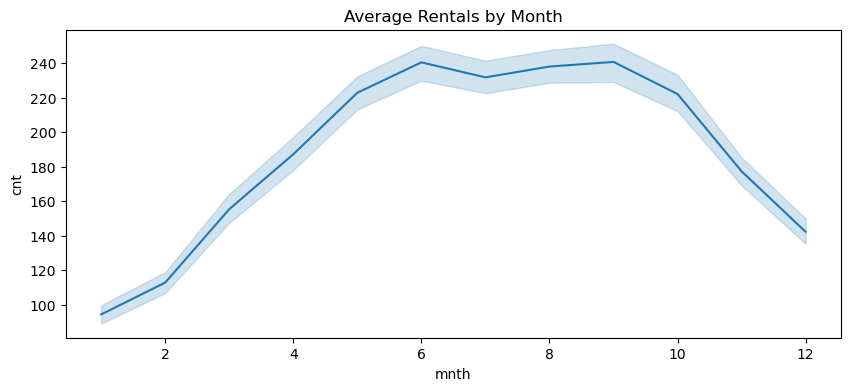

In [9]:
# 3. Monthly Patterns 
plt.figure(figsize=(10, 4))
sns.lineplot(data=df, x='mnth', y='cnt')
plt.title('Average Rentals by Month')
plt.show()

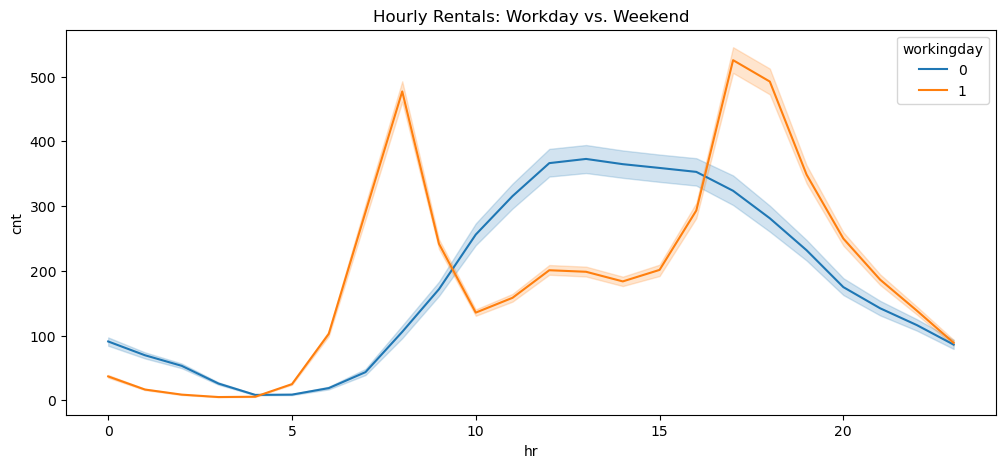

In [10]:
plt.figure(figsize=(12, 5))
# 'workingday' is 1 for Mon-Fri, and 0 for Weekends/Holidays
sns.lineplot(data=df, x='hr', y='cnt', hue='workingday')
plt.title('Hourly Rentals: Workday vs. Weekend')
plt.show()

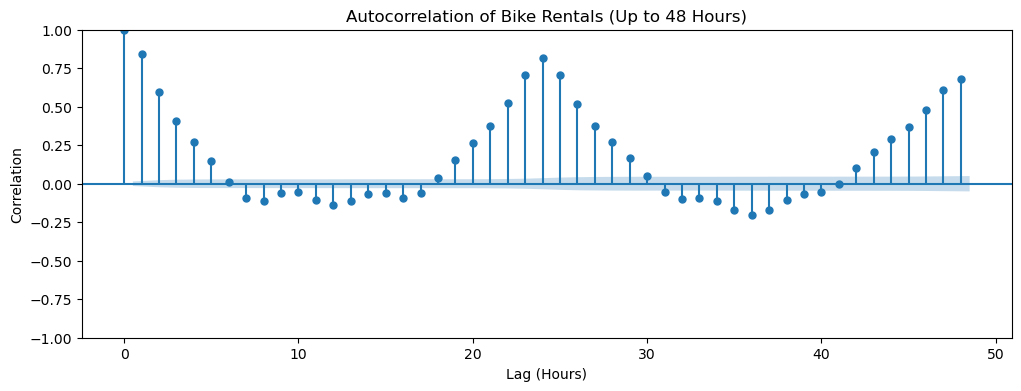

In [11]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12, 4))
# We check the correlation for the last 48 hours (lags=48)
plot_acf(df['cnt'], lags=48, ax=plt.gca())
plt.title('Autocorrelation of Bike Rentals (Up to 48 Hours)')
plt.xlabel('Lag (Hours)')
plt.ylabel('Correlation')
plt.show()

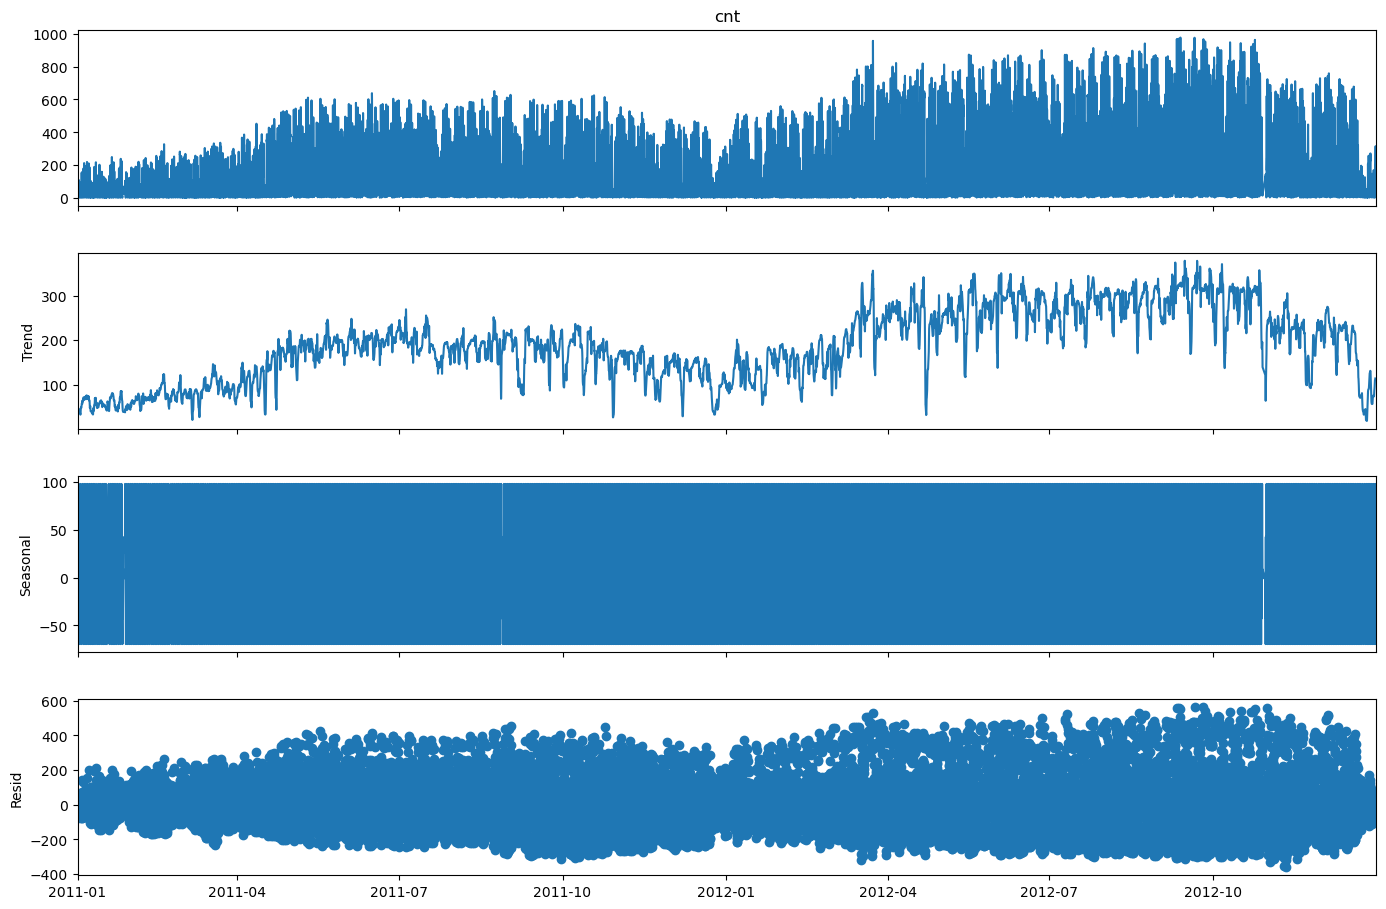

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose

# We use period=24 because there are 24 hours in a daily cycle
decomposition = seasonal_decompose(df['cnt'], model='additive', period=24)

# Plotting
fig = decomposition.plot()
fig.set_size_inches(15, 10)
plt.show()

Step 3: Feature Engineering

In [13]:
# 1. Create Lag Features (Memory of specific past hours)
df['lag_1'] = df['cnt'].shift(1)   # Rentals exactly 1 hour ago
df['lag_2'] = df['cnt'].shift(2)   # Rentals exactly 2 hours ago
df['lag_24'] = df['cnt'].shift(24) # Rentals exactly 24 hours ago (this time yesterday)

# 2. Create Rolling Statistics (Recent Momentum/Trend)
# We calculate the average of the last 24 hours. 
# Notice we shift by 1 FIRST, so we don't accidentally include the current hour!
df['rolling_mean_24h'] = df['cnt'].shift(1).rolling(window=24).mean()

# 3. Drop the empty rows created by shifting
# The first 24 rows won't have a 'lag_24' available, so they become NaN (Not a Number).
# Machine learning models crash if they see NaNs, so we drop them.
df.dropna(inplace=True)

# Let's look at our new engineered dataset!
print(df[['cnt', 'lag_1', 'lag_24', 'rolling_mean_24h']].head())

                     cnt  lag_1  lag_24  rolling_mean_24h
datetime                                                 
2011-01-02 00:00:00   17   39.0    16.0         41.041667
2011-01-02 01:00:00   17   17.0    40.0         41.083333
2011-01-02 02:00:00    9   17.0    32.0         40.125000
2011-01-02 03:00:00    6    9.0    13.0         39.166667
2011-01-02 04:00:00    3    6.0     1.0         38.875000


Step 4: Modeling

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Select the features we want the model to learn from
features = [
    'hr', 'mnth', 'yr', 'workingday', 'weathersit', 
    'temp', 'hum', 'windspeed', 
    'lag_1', 'lag_2', 'lag_24', 'rolling_mean_24h'
]
target = 'cnt'

X = df[features]
y = df[target]

# 2. Perform a Time-Aware Split (Chronological, NO SHUFFLING!)
# We will use the first 80% of the timeline to train, and the last 20% to test.
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Training on {len(X_train)} hours from the past...")
print(f"Testing on {len(X_test)} hours from the future...\n")

# 3. Initialize the Random Forest Model
# n_estimators=100 (100 trees), random_state=42 (lock the randomness)
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 4. Train the Model! (This might take 10-20 seconds)
print("Training the Random Forest...")
model.fit(X_train, y_train)
print("Training Complete!")

# 5. Make predictions on the unseen future data
predictions = model.predict(X_test)

Training on 13884 hours from the past...
Testing on 3471 hours from the future...

Training the Random Forest...
Training Complete!


In [ ]:
Step 5: Evaluation

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ---------------------------------------------------------
# 1. EVALUATE YOUR RANDOM FOREST
# ---------------------------------------------------------
# Calculate how many bikes the model was off by on average
rf_mae = mean_absolute_error(y_test, predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("--- RANDOM FOREST PERFORMANCE ---")
print(f"Mean Absolute Error (MAE): {rf_mae:.2f} bikes")
print(f"Root Mean Squared Error (RMSE): {rf_rmse:.2f} bikes\n")

# ---------------------------------------------------------
# 2. CREATE AND EVALUATE THE BASELINE
# ---------------------------------------------------------
# The Persistence Baseline: "Next hour's rentals will be the same as this hour's"
# We simulate this by shifting the actual test answers down by 1 hour
baseline_predictions = y_test.shift(1)

# Drop the first row (which becomes NaN after shifting) from both sets to be fair
y_test_clean = y_test[1:]
baseline_clean = baseline_predictions[1:]

base_mae = mean_absolute_error(y_test_clean, baseline_clean)
base_rmse = np.sqrt(mean_squared_error(y_test_clean, baseline_clean))

print("--- PERSISTENCE BASELINE PERFORMANCE ---")
print(f"Mean Absolute Error (MAE): {base_mae:.2f} bikes")
print(f"Root Mean Squared Error (RMSE): {base_rmse:.2f} bikes\n")

# ---------------------------------------------------------
# 3. THE VERDICT
# ---------------------------------------------------------
improvement = base_mae - rf_mae
print("--- THE VERDICT ---")
print(f"Your model beats the baseline by an average of {improvement:.2f} bikes per hour!")

--- RANDOM FOREST PERFORMANCE ---
Mean Absolute Error (MAE): 32.02 bikes
Root Mean Squared Error (RMSE): 53.80 bikes

--- PERSISTENCE BASELINE PERFORMANCE ---
Mean Absolute Error (MAE): 85.12 bikes
Root Mean Squared Error (RMSE): 129.54 bikes

--- THE VERDICT ---
Your model beats the baseline by an average of 53.11 bikes per hour!
